# SOLUTION TO THE MINI PROJECT ON MULTIPLE LINEAR REGRESSION

Mini Project: Perform Multiple Linear Regression

Overview
This project focuses on using multiple linear regression to analyze the relationship between sales and various marketing promotion strategies. By leveraging multiple independent variables, such as TV, social media, radio, and influencer promotions, we aim to build a predictive model that estimates sales based on these factors. This project will cover the complete data science pipeline, including data exploration, preprocessing, model building, evaluation, and interpretation.

Objective
Develop a multiple linear regression model to predict sales based on marketing promotion data. The project will involve exploring the dataset, selecting relevant independent variables, fitting the model, checking assumptions, and interpreting the results to provide actionable insights.

Learning Outcomes
Understand the concept of multiple linear regression and its applications.
Learn to preprocess and explore data for regression analysis.
Gain experience in fitting and evaluating a multiple linear regression model.
Check and validate regression assumptions.
Interpret model coefficients and communicate results to stakeholders.

In [15]:
# Step 1: Load and Inspect the Dataset

import pandas as pd

# Load the dataset
file_path = 'C:/Users/PAUL ROSE/Desktop/Courses/3MTT/Training Data/linear regression/marketing_sales_data.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
df.head()


,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


In [14]:
# Step 2: Data Exploration and Cleaning

# Summary statistics and data types

df.describe()

# Check for missing values
df.isnull().sum()

# Check data types to identify categorical variables
df.dtypes


TV               object
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object

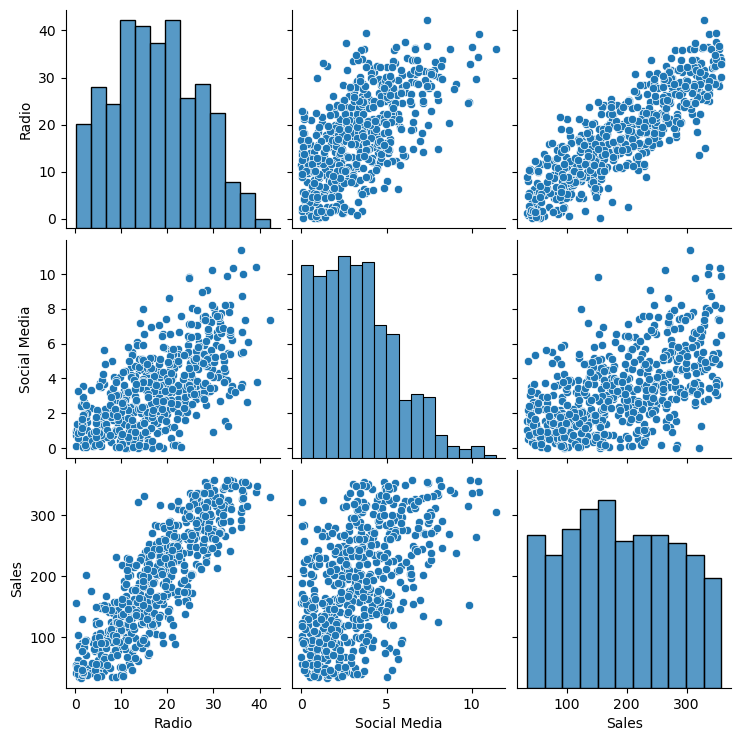

In [17]:
# Step 3: Visualizing Relationships with Pairplot

import seaborn as sns
import matplotlib.pyplot as plt

# Plot pairplot to visualize relationships between variables
sns.pairplot(df)
plt.show()


In [22]:
# Step 4: Data Preprocessing

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Drop rows with missing values
df_cleaned = df.dropna()

# If there are categorical variables, encode them
# Example: Let's assume 'Category' is a categorical feature
if 'Category' in df_cleaned.columns:
    label_encoder = LabelEncoder()
    df_cleaned['Category'] = label_encoder.fit_transform(df_cleaned['Category'])

# Split the data into features (X) and target (y)
X = df_cleaned.drop('Sales', axis=1)  # Assuming 'Sales' is the target variable
y = df_cleaned['Sales']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Check and Encode Categorical Variables:

from sklearn.preprocessing import LabelEncoder

# Check data types to identify categorical variables
print(df.dtypes)

# If any categorical columns exist (e.g., 'Category'), encode them using LabelEncoder or OneHotEncoder
categorical_columns = df.select_dtypes(include=['object']).columns

# Encode categorical columns using LabelEncoder (for simple cases)
label_encoder = LabelEncoder()
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

# Now split the data into features (X) and target (y)
X = df.drop('Sales', axis=1)  # Assuming 'Sales' is the target variable
y = df['Sales']

# Split the data into training and testing sets (80% train, 20% test)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


TV               object
Radio           float64
Social Media    float64
Influencer       object
Sales           float64
dtype: object


LinearRegression()

In [28]:
# Step 5: Fit the Multiple Linear Regression Model

from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Fit the model to the training data
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)


In [26]:
#Step 6: Define the OLS Formula and Fit Using Statsmodels 

import statsmodels.api as sm

# Add a constant to the features for the intercept term in OLS
X_train_ols = sm.add_constant(X_train)

# Fit the OLS model
ols_model = sm.OLS(y_train, X_train_ols).fit()

# Print the model summary
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     356.5
Date:                Wed, 02 Apr 2025   Prob (F-statistic):          2.72e-138
Time:                        22:03:58   Log-Likelihood:                -2379.8
No. Observations:                 457   AIC:                             4770.
Df Residuals:                     452   BIC:                             4790.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           59.4644      7.158      8.308   

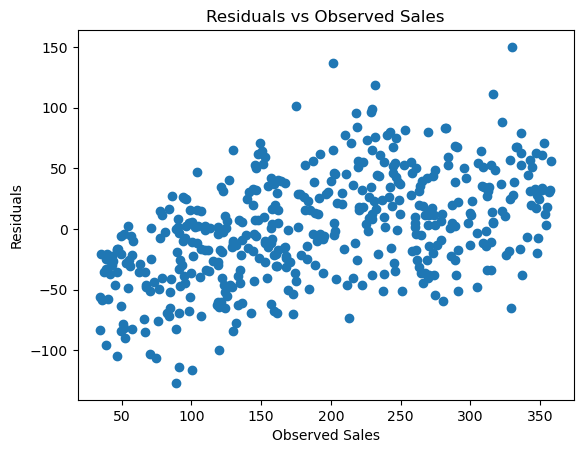

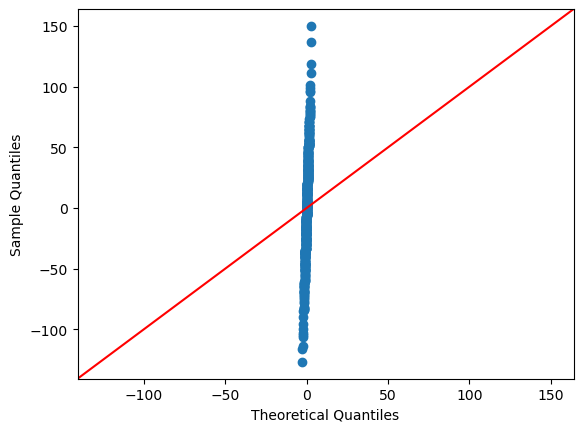

In [29]:
# Step 7: Check Regression Assumptions
# Residuals for checking normality
residuals = y_train - ols_model.predict(X_train_ols)

# Scatter plot to check linearity assumption
plt.scatter(y_train, residuals)
plt.xlabel('Observed Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Observed Sales')
plt.show()

# Q-Q plot to check normality of residuals
sm.qqplot(residuals, line ='45')
plt.show()


In [ ]:
# Step 8: Interpret the Model Results

# Display model summary (already printed in the previous step)
# You can refer to the summary to interpret the coefficients, R-squared, and p-values.


In [31]:
# Assuming you have already fitted the OLS model using statsmodels
import statsmodels.api as sm

# Add a constant to the features for the intercept term
X_train_ols = sm.add_constant(X_train)

# Fit the OLS model
ols_model = sm.OLS(y_train, X_train_ols).fit()

# Display the model summary
model_summary = ols_model.summary()
print(model_summary)

# Extract R-squared, Coefficients, and P-values
r_squared = ols_model.rsquared
coefficients = ols_model.params
p_values = ols_model.pvalues

# Print interpretation of R-squared, coefficients, and p-values
print(f"R-squared: {r_squared:.4f}")
print("\nCoefficients:")
print(coefficients)
print("\nP-values:")
print(p_values)

# Additional interpretation
for feature, coef, p_value in zip(coefficients.index, coefficients.values, p_values):
    print(f"Feature: {feature}, Coefficient: {coef:.4f}, P-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"  => The feature '{feature}' is statistically significant.")
    else:
        print(f"  => The feature '{feature}' is not statistically significant.")


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     356.5
Date:                Wed, 02 Apr 2025   Prob (F-statistic):          2.72e-138
Time:                        22:44:54   Log-Likelihood:                -2379.8
No. Observations:                 457   AIC:                             4770.
Df Residuals:                     452   BIC:                             4790.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           59.4644      7.158      8.308   